this is the first docuement

tfidf

TF - tere frequency - number of time 'this' appear in docuement/total number of docuement
idf - inverse docuement frequency = log(total no of docuement)
number of docuement which has 'this word
'

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [53]:
vectorizer = TfidfVectorizer()

In [54]:
corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?',
]

In [55]:
X = vectorizer.fit_transform(corpus)

In [56]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (4, 9)>

In [57]:
corpus

['This is the first document.',
 'This document is the second document.',
 'And this is the third one.',
 'Is this the first document?']

In [58]:
X.toarray()

array([[0.        , 0.46979139, 0.58028582, 0.38408524, 0.        ,
        0.        , 0.38408524, 0.        , 0.38408524],
       [0.        , 0.6876236 , 0.        , 0.28108867, 0.        ,
        0.53864762, 0.28108867, 0.        , 0.28108867],
       [0.51184851, 0.        , 0.        , 0.26710379, 0.51184851,
        0.        , 0.26710379, 0.51184851, 0.26710379],
       [0.        , 0.46979139, 0.58028582, 0.38408524, 0.        ,
        0.        , 0.38408524, 0.        , 0.38408524]])

In [59]:
vectorizer.get_feature_names_out()

array(['and', 'document', 'first', 'is', 'one', 'second', 'the', 'third',
       'this'], dtype=object)

In [60]:
from sklearn.datasets import fetch_20newsgroups

In [61]:
data = fetch_20newsgroups()

In [62]:
dir(data)

['DESCR', 'data', 'filenames', 'target', 'target_names']

In [63]:
data.target

array([7, 4, 4, ..., 3, 1, 8])

In [64]:
data.data[0]

"From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n"

In [65]:
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [66]:
len(data.target_names)

20

In [67]:
data.target[7]

np.int64(3)

In [68]:
categaries = data.target_names

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33, random_state=42)

In [71]:
len(X_train)

7580

In [72]:
len(y_test)

3734

In [73]:
data.target

array([7, 4, 4, ..., 3, 1, 8])

In [74]:
from sklearn.naive_bayes import MultinomialNB

In [75]:
from sklearn.pipeline import Pipeline

In [76]:
model = Pipeline([("vectorizer",TfidfVectorizer()),("mb",MultinomialNB())])

In [77]:
model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer()), ('mb', MultinomialNB())])

In [78]:
model.score(X_test, y_test)

0.8403856454204607

In [79]:
y_pred = model.predict(X_test)

In [80]:
y_pred

array([ 3,  2,  6, ..., 15, 17,  9])

In [81]:
from sklearn.metrics import confusion_matrix

In [82]:
cm = confusion_matrix(y_test, y_pred)

In [83]:
cm

array([[112,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
          0,   0,  33,   0,   2,   0,   0],
       [  0, 140,   5,   6,   1,   8,   3,   1,   0,   1,   0,   2,   0,
          0,   2,   5,   1,   0,   0,   0],
       [  0,   8, 140,  22,   0,   7,   2,   0,   0,   2,   1,   5,   0,
          0,   1,   3,   0,   0,   0,   0],
       [  0,   5,   5, 165,   4,   1,   3,   0,   0,   0,   0,   7,   3,
          0,   0,   4,   0,   0,   0,   0],
       [  0,   3,   2,  17, 153,   1,   2,   1,   0,   1,   3,   6,   1,
          1,   2,   4,   0,   0,   0,   0],
       [  0,   7,   0,   3,   0, 166,   1,   1,   2,   1,   0,   2,   0,
          0,   1,   4,   0,   0,   0,   0],
       [  0,   1,   3,  16,   1,   1, 129,   9,   5,   0,   1,   6,   4,
          2,   1,   8,   1,   0,   0,   0],
       [  0,   0,   0,   1,   1,   0,   2, 186,   3,   1,   0,   0,   3,
          0,   1,   9,   0,   0,   0,   0],
       [  0,   0,   0,   1,   0,   0,   1,   8, 195,   0,   1,  

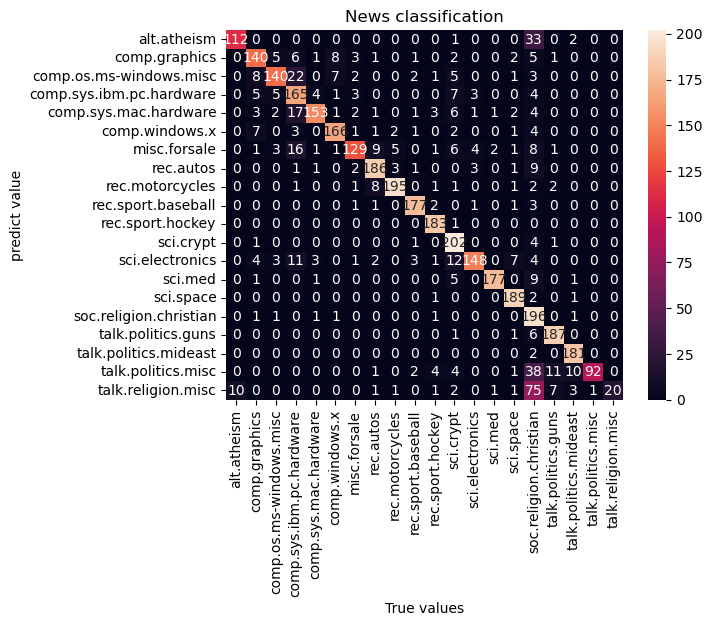

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d",xticklabels=categaries,yticklabels=categaries)
plt.xlabel("True values")
plt.ylabel("predict value")
plt.title("News classification")
plt.show()

In [85]:
from sklearn.feature_extraction.text import CountVectorizer

In [86]:
from sklearn.naive_bayes import BernoulliNB

In [87]:
from sklearn.pipeline import Pipeline

In [88]:
model = Pipeline([("vectorizer",CountVectorizer()),("bb",BernoulliNB())])

In [89]:
model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('bb', BernoulliNB())])

In [90]:
model.score(X_test, y_test)

0.6355115158007498

In [91]:
y_pred = model.predict(X_test)

In [92]:
y_pred 

array([ 6,  3,  6, ..., 15, 17,  9])

In [93]:
from sklearn.metrics import confusion_matrix

In [94]:
cm = confusion_matrix(y_test, y_pred)

In [95]:
cm

array([[ 55,   4,   0,   6,   0,   0,  11,   0,   0,  41,   0,   1,   1,
          0,   0,  29,   0,   0,   0,   0],
       [  0, 130,   0,   6,   0,   5,  33,   0,   0,   0,   0,   1,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,  40,   4,  83,   4,  11,  43,   0,   0,   0,   0,   1,   5,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   7,   0, 149,   0,   0,  39,   0,   0,   0,   0,   0,   2,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   2,   0,  17, 116,   1,  54,   0,   0,   1,   0,   1,   4,
          0,   0,   1,   0,   0,   0,   0],
       [  0,  19,   0,   1,   1, 134,  32,   0,   0,   1,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   6,   1,   0, 170,   6,   0,   0,   1,   0,   4,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   1,   0,   2,   0,   0,  45, 155,   2,   0,   0,   0,   2,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   1,   0,   1,  33,   5, 166,   3,   0,  

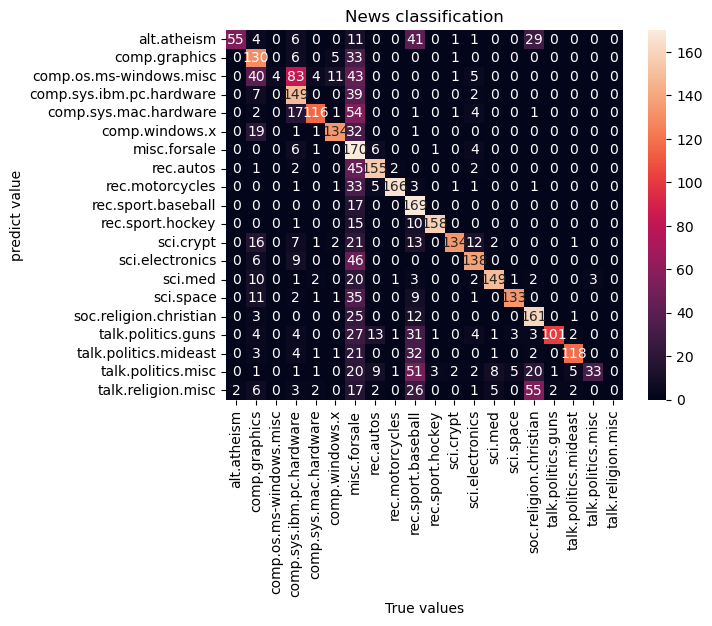

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d",xticklabels=categaries,yticklabels=categaries)
plt.xlabel("True values")
plt.ylabel("predict value")
plt.title("News classification")
plt.show()